# 05.25 - Neural Network Foundations

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Neural networks learn complex patterns by stacking simple, differentiable functions. They are the foundation of deep learning.

## 2. Why Does This Matter?

Neural networks power modern AI: image recognition, NLP, speech. Understanding them is essential.

## 3. Prerequisites

- 05.03: Logistic regression
- Basic calculus (derivatives)

## 4. Learning Objectives

- Understand neurons, layers, activation functions
- Implement forward propagation from scratch
- Understand backpropagation conceptually
- Build a simple neural network with PyTorch

## 5. Mental Model

Neuron = linear combination + activation.
Layer = group of neurons.
Network = stack of layers.
Learning = adjust weights to minimize loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. The Neuron

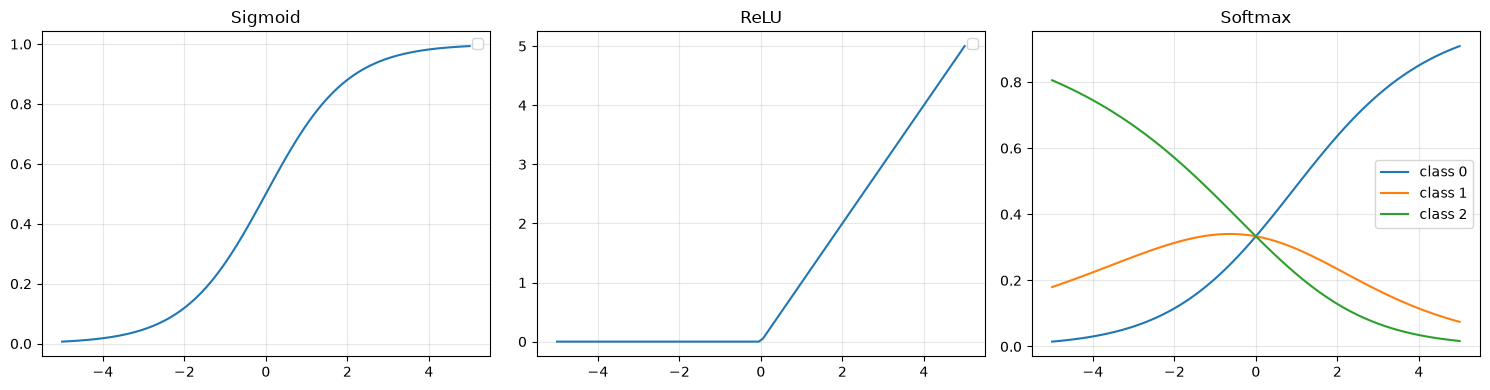

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

z = np.linspace(-5, 5, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, func, name in zip(axes, [sigmoid, relu, softmax], ["Sigmoid", "ReLU", "Softmax"]):
    if name == "Softmax":
        z2 = np.column_stack([z, z*0.5, z*0.2])
        out = func(z2)
        for i in range(3):
            ax.plot(z, out[:, i], label=f"class {i}")
    else:
        ax.plot(z, func(z))
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig("activations.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Forward Propagation from Scratch

In [3]:
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

nn = SimpleNN(4, 8, 3)
X_dummy = np.random.randn(5, 4)
out = nn.forward(X_dummy)
print("Output shape:", out.shape)
print("Sum per sample (should be 1.0):", out.sum(axis=1))

Output shape: (5, 3)
Sum per sample (should be 1.0): [1. 1. 1. 1. 1.]


## 8. Loss Function

In [4]:
def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[np.arange(m), y_true] + 1e-8)
    return np.mean(log_likelihood)

loss = cross_entropy_loss(out, np.array([0, 1, 2, 1, 0]))
print("Cross-entropy loss:", round(float(loss), 4))

Cross-entropy loss: 1.0986


## 9. PyTorch Introduction

In [5]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("PyTorch version:", torch.__version__)
except ImportError:
    print("PyTorch not installed.")

PyTorch version: 2.13.0+cpu


In [6]:
class TorchNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )
    
    def forward(self, x):
        return self.layers(x)

model = TorchNN()
X_t = torch.randn(5, 4)
out_t = model(X_t)
print("PyTorch output shape:", out_t.shape)

PyTorch output shape: torch.Size([5, 3])


## 10. Common Mistakes

1. Sigmoid in output layer (use softmax)
2. Not normalizing inputs
3. Too large learning rate
4. Vanishing gradients with deep networks

## 11. Coding Exercises

### Exercise 1: Two-Layer NN from Scratch
Implement a 2-layer NN with backprop.

### Exercise 2: MNIST with PyTorch
Train on MNIST digits.

In [7]:
# EXERCISE 1: Two-layer NN
print("Exercise: Implement 2-layer NN with backpropagation.")

Exercise: Implement 2-layer NN with backpropagation.


In [8]:
# EXERCISE 2: MNIST
try:
    from sklearn.datasets import load_digits
    digits = load_digits()
    print("Digits shape:", digits.data.shape)
except Exception as e:
    print("Error:", e)

Digits shape: (1797, 64)


## 12. Closed-Book Recall

1. What does a neuron compute?
2. Why use ReLU over sigmoid?
3. What is cross-entropy loss?
4. How does backpropagation work?

## 13. Teach-Back Questions

Explain forward propagation. How gradients flow backward. Why activation functions matter.

## 14. Summary

Neurons compute linear + activation. Networks stack layers. Forward prop computes output. Backprop computes gradients. PyTorch automates this.

## 15. Further Experiment

1. Implement backprop from scratch.
2. Try different architectures.
3. Visualize learned weights.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, matplotlib, torch]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```